In [ ]:
!pip install wandb

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 323.4/323.4 kB 16.3 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 7.34.1
    Uninstalling protobuf-7.34.1:
      Successfully uninstalled protobuf-7.34.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-ai-generativelanguage 0.6.15 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<6.0.0dev,>=3.20.2, but you have protobuf 6.33.6 which is incompatible.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2025.9.0 which is incompatible.
google-adk 1.27.1 requires websockets<16.0.0,>=15.0.1, but you have websockets 16.0 which is incompatible.
tensorflow 2.19.0 requires numpy<2.2.0,>=1.26.0, but you have numpy 2.4.3 which is incompatible.
tensorflow 2.19.0 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<6.0.0dev,>=3.2

In [ ]:
# import wandb
# wandb.login()

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
wandb: Currently logged in as: huyhoang20451 (huyhoang20451-fpt-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [ ]:
import pandas as pd
import re
import json
from datasets import load_dataset

In [ ]:
# Load the dataset from Hugging Face
dataset = load_dataset("usernone1234/capstone-llm-project-SP26AI20")

# dataset.head() # This line caused an AttributeError.
# load_dataset returns a DatasetDict, not a single dataset or dataframe.
# To view the head, access a specific split (e.g., 'train') and convert to pandas.
if 'train' in dataset:
    print("First 5 rows of the 'train' split:")
    print(dataset['train'].to_pandas().head())
elif len(dataset) > 0:
    # If no 'train' split, try the first available split
    first_split_key = list(dataset.keys())[0]
    print(f"No 'train' split found. Displaying first 5 rows of the '{first_split_key}' split:")
    print(dataset[first_split_key].to_pandas().head())
else:
    print("Dataset loaded but no splits found to display.")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


First 5 rows of the 'train' split:
                                          user_query    Emotion  \
0  Mình vừa tham gia một buổi tư vấn sức khỏe tâm...     Vui vẻ   
1  Em mệt với việc lúc nào cũng bị so sánh điểm v...  Chán ghét   
2  Em thấy mình quá chậm chạp khi bắt đầu học một...      Lo âu   
3                            Ai sẽ đón em chiều nay?      Other   
4                             Ai sẽ nấu cơm tối nay?      Other   

                                            response  
0  Thật hạnh phúc khi bạn đã tìm thấy một không g...  
1  Sự mệt mỏi của bạn là rất dễ hiểu. So sánh liê...  
2  Mỗi người có một nhịp độ tiếp thu khác nhau và...  
3  Đây là câu hỏi sinh hoạt thường ngày. Bạn có t...  
4  Đây là câu hỏi sinh hoạt thường ngày. Bạn có t...  


In [ ]:
# Format instruction
def format_instruction(samples):
  user_queries = samples['user_query']
  emotions = samples['Emotion']
  responses = samples['response']
  texts = []

  for user_query, emotion, response in zip(user_queries, emotions, responses):
    instruction = f"""
    <im_start>system
  Bạn là AI nhận diện cảm xúc trong văn bản tiếng Việt.

  Nhiệm vụ:
  - Xác định cảm xúc của câu người dùng
  - Sau đó phản hồi lại một câu phù hợp với cảm xúc đó

  Các cảm xúc hợp lệ:
  - Buồn bã
  - Lo âu
  - Lạc quan
  - Cô đơn
  - Other
  - Vui vẻ
  - Chán ghét
  - Ngạc nhiên
  - Sợ hãi
  - Tức giận
  - Highly Negative
  - Trung lập
  - Hối tiếc

  Yêu cầu:
  - Trả về JSON
  - Không giải thích
  - Format gồm:
    + emotion: nhãn cảm xúc
    + response: câu phản hồi phù hợp
  <im_end>

  <im_start>user
  {user_query}
  <im_end>

  <im_start>assistant
  {{
    "emotion": "{emotion}",
    "response": "{response}"
  }}
  <im_end>
    """
    texts.append(instruction)
  return {'text': texts}

# Split the 'train' dataset into training and validation sets
train_test_split_dataset = dataset['train'].train_test_split(test_size=0.1, seed=42)

# Call format_instruction on the new 'train' and 'test' (validation) splits
formatted_train_dataset = train_test_split_dataset['train'].map(format_instruction, batched=True)
formatted_validation_dataset = train_test_split_dataset['test'].map(format_instruction, batched=True)

In [ ]:
formatted_train_dataset[1]

{'user_query': 'Nhà có đủ người mà em chẳng biết tâm sự với ai.',
 'Emotion': 'Cô đơn',
 'response': 'Cảm giác cô đơn này rất khó nói ra. Ở gần mà không gần là điều nhiều người gặp. Điều đó không làm bạn khác lạ. bạn có thể thử mở lòng với một người dễ nói nhất. Một kết nối đủ sâu cũng giúp bạn đỡ lạc lõng.',
 'text': '\n    <im_start>system\n  Bạn là AI nhận diện cảm xúc trong văn bản tiếng Việt.\n\n  Nhiệm vụ:\n  - Xác định cảm xúc của câu người dùng\n  - Sau đó phản hồi lại một câu phù hợp với cảm xúc đó\n\n  Các cảm xúc hợp lệ:\n  - Buồn bã\n  - Lo âu\n  - Lạc quan\n  - Cô đơn\n  - Other\n  - Vui vẻ\n  - Chán ghét\n  - Ngạc nhiên\n  - Sợ hãi\n  - Tức giận\n  - Highly Negative\n  - Trung lập\n  - Hối tiếc\n\n  Yêu cầu:\n  - Trả về JSON\n  - Không giải thích\n  - Format gồm:\n    + emotion: nhãn cảm xúc\n    + response: câu phản hồi phù hợp\n  <im_end>\n\n  <im_start>user\n  Nhà có đủ người mà em chẳng biết tâm sự với ai.\n  <im_end>\n\n  <im_start>assistant\n  {\n    "emotion": "Cô 

In [ ]:
#@title Colab Extra Install { display-mode: "form" }
%%capture
import os
!pip install --upgrade -qqq uv
if "COLAB_" not in "".join(os.environ.keys()):
    # If you're not in Colab, just use pip install!
    !pip install unsloth vllm
else:
    try: import numpy, PIL; _numpy = f'numpy=={numpy.__version__}'; _pil = f'pillow=={PIL.__version__}'
    except: _numpy = "numpy"; _pil = "pillow"
    try: import subprocess; is_t4 = "Tesla T4" in str(subprocess.check_output(["nvidia-smi"]))
    except: is_t4 = False
    _vllm, _triton = ('vllm==0.9.2', 'triton==3.2.0') if is_t4 else ('vllm==0.15.1', 'triton')
    !uv pip install -qqq --upgrade {_vllm} {_numpy} {_pil} torchvision bitsandbytes xformers unsloth
    !uv pip install -qqq {_triton}
!uv pip install transformers==4.56.2
!uv pip install --no-deps trl==0.22.2

In [ ]:
import os
# Attempt to upgrade scipy and numpy to resolve 'KeyError: has ilp64'
# This is done before importing unsloth, as the error occurs during unsloth's initialization.
# A runtime restart might be necessary after running this cell for the changes to fully apply.
try:
    # Assuming 'uv' is installed from the previous cell (S-druyEyvAbi)
    !uv pip install -qqq --upgrade scipy numpy
except Exception as e:
    print(f"Warning: uv failed, trying pip. Error: {e}")
    !pip install -qqq --upgrade scipy numpy

from unsloth import FastLanguageModel
import torch
max_seq_length = 1024 #
lora_rank = 32 # Larger rank = smarter, but slower

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = "unsloth/Qwen2.5-1.5B-Instruct",
    max_seq_length = max_seq_length,
    load_in_4bit = True, # Changed to True for proper quantization and device placement
    fast_inference = False, # Disable vllm fast inference for troubleshooting
    gpu_memory_utilization = 0.9, # Reduce if out of memory
    device_map = "cuda" # Explicitly map to CUDA
)

# Explicitly set the chat template for the tokenizer
tokenizer.chat_template = (
    "{% for message in messages %}"
        "{% if message['role'] == 'user' %}"
            "{{ '<|im_start|>user\n' + message['content'] + '<|im_end|>\n' }}"
        "{% elif message['role'] == 'system' %}"
            "{{ '<|im_start|>system\n' + message['content'] + '<|im_end|>\n' }}"
        "{% elif message['role'] == 'assistant' %}"
            "{{ '<|im_start|>assistant\n' + message['content'] + '<|im_end|>\n' }}"
        "{% endif %}"
    "{% endfor %}"
    "{% if add_generation_prompt %}"
        "{{ '<|im_start|>assistant\n' }}"
    "{% endif %}"
)

model = FastLanguageModel.get_peft_model(
    model,
    r = lora_rank, # Choose any number > 0 ! Suggested 8, 16, 32, 64, 128
    target_modules = [
        "q_proj", "k_proj", "v_proj", "o_proj",
        "gate_proj", "up_proj", "down_proj",
    ],
    lora_alpha = lora_rank*2, # *2 speeds up training
    use_gradient_checkpointing = "unsloth", # Reduces memory usage
    random_state = 3407,
)

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
INFO 03-28 13:48:06 [__init__.py:244] Automatically detected platform cuda.
ERROR 03-28 13:48:15 [fa_utils.py:57] Cannot use FA version 2 is not supported due to FA2 is only supported on devices with compute capability >= 8
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.3.17: Fast Qwen2 patching. Transformers: 4.56.2. vLLM: 0.9.2.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.7.0+cu126. CUDA: 7.5. CUDA Toolkit: 12.6. Triton: 3.2.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.30. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/1.53G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/270 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

added_tokens.json:   0%|          | 0.00/605 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/614 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

unsloth/qwen2.5-1.5b-instruct-unsloth-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.


Unsloth 2026.3.17 patched 28 layers with 28 QKV layers, 28 O layers and 28 MLP layers.


In [ ]:
from trl import SFTTrainer
import math
from transformers import TrainingArguments, TrainerCallback
from unsloth import is_bfloat16_supported

class LoggingCallback(TrainerCallback):
    def on_log(self, args, state, control, logs=None, **kwargs):
        # Tính Perplexity từ Training Loss
        if logs is not None and "loss" in logs:
            try:
                logs["perplexity"] = math.exp(logs["loss"])
            except OverflowError:
                logs["perplexity"] = float("inf")

        # Tính Perplexity từ Validation Loss (khi có bước evaluate)
        if logs is not None and "eval_loss" in logs:
            try:
                logs["eval_perplexity"] = math.exp(logs["eval_loss"])
            except OverflowError:
                logs["eval_perplexity"] = float("inf")

wandb.init(
    project = "finetune-llm",
    name = "Qwen2.5-1.5B-Instruct-TamLyVN-v1",
    config = {
        "learning_rate": 2e-4,
        "dataset": "capstone-llm-project-SP26AI20",
    }
)

trainer_sft = SFTTrainer(
    model = model,
    tokenizer = tokenizer,
    train_dataset = formatted_train_dataset, # Use the new formatted training dataset
    eval_dataset = formatted_validation_dataset, # Add the formatted validation dataset
    dataset_text_field = "text",
    max_seq_length = max_seq_length,
    dataset_num_proc = 2,
    args = TrainingArguments(
        per_device_train_batch_size = 2,
        gradient_accumulation_steps = 8,
        eval_strategy="steps",
        eval_steps=15,
        warmup_steps = 10,
        max_steps = 500, # 500 bước để mô hình học sâu hơn các ngõ ngách vấn đề
        learning_rate = 2e-4,
        fp16 = not is_bfloat16_supported(),
        bf16 = is_bfloat16_supported(),
        logging_steps = 1,
        optim = "adamw_8bit",
        weight_decay = 0.01,
        lr_scheduler_type = "linear",
        seed = 3407,
        output_dir = "outputs_sft",
        report_to = "wandb",               # Gửi log đến Wandb
        run_name = "qwen2.5-1.5b-sft-v1",  # Tên hiển thị của run
        logging_first_step = True
    ),
    callbacks = [LoggingCallback()]
)

trainer_sft.train()

wandb.finish()

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 9,818 | Num Epochs = 1 | Total steps = 500
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 8
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 8 x 1) = 16
 "-____-"     Trainable parameters = 36,929,536 of 1,580,643,840 (2.34% trained)


Step,Training Loss,Validation Loss,Perplexity
15,0.361100,0.533553,1.704979
30,0.476000,0.521237,1.684109
45,0.528000,0.507374,1.660923
60,0.586400,0.496262,1.642571
75,0.402600,0.492092,1.635735
90,0.520500,0.482744,1.620515
105,0.440300,0.477010,1.611249
120,0.568300,0.472257,1.603609
135,0.508500,0.467611,1.596176
150,0.553300,0.463209,1.589165


eval/loss,█▇▆▆▅▅▅▄▄▄▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁
eval/runtime,▅▆▄▄▇█▆▅▃▃▄▅▆▄▆▄▇▆▄▄▂▄▂▃▄▄▄▃▄▂▁▃▃
eval/samples_per_second,▄▃▅▅▂▁▃▄▆▆▅▄▃▅▃▅▂▃▅▅▇▅▇▆▄▅▅▆▅▇█▆▆
eval/steps_per_second,▄▃▅▅▂▁▃▄▆▆▅▄▃▅▃▅▂▃▅▅▇▅▇▆▅▅▅▆▅▇█▆▆
train/epoch,▁▁▁▁▁▁▁▂▂▂▂▂▂▂▂▃▃▄▄▄▄▄▄▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇█
train/global_step,▁▁▁▁▂▂▃▃▃▃▃▃▃▃▃▃▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▆▇██████
train/grad_norm,▃▅▆▄█▇▆▄▆▂▄▃▃▃▃▃▃▄▅▃▃▃▁▃▂▃▃▅▅▄▃▃▄▄▃▄▂▄▄▅
train/learning_rate,██▇▇▇▆▆▆▆▆▅▅▅▅▅▅▅▅▄▄▄▄▃▃▃▃▃▃▃▃▃▂▂▂▂▂▂▂▁▁
train/loss,▅▂▆▄▅▆▅▂▅▅▃█▅▅▃▄▁▄▄▄▃▂▄▃▃▆▆▅▂▃▃▃▂▅▆▃▁▃▂▄
eval/loss,0.41938
eval/runtime,98.1128


Số điểm dữ liệu Train: 500
Số điểm dữ liệu Validation: 33


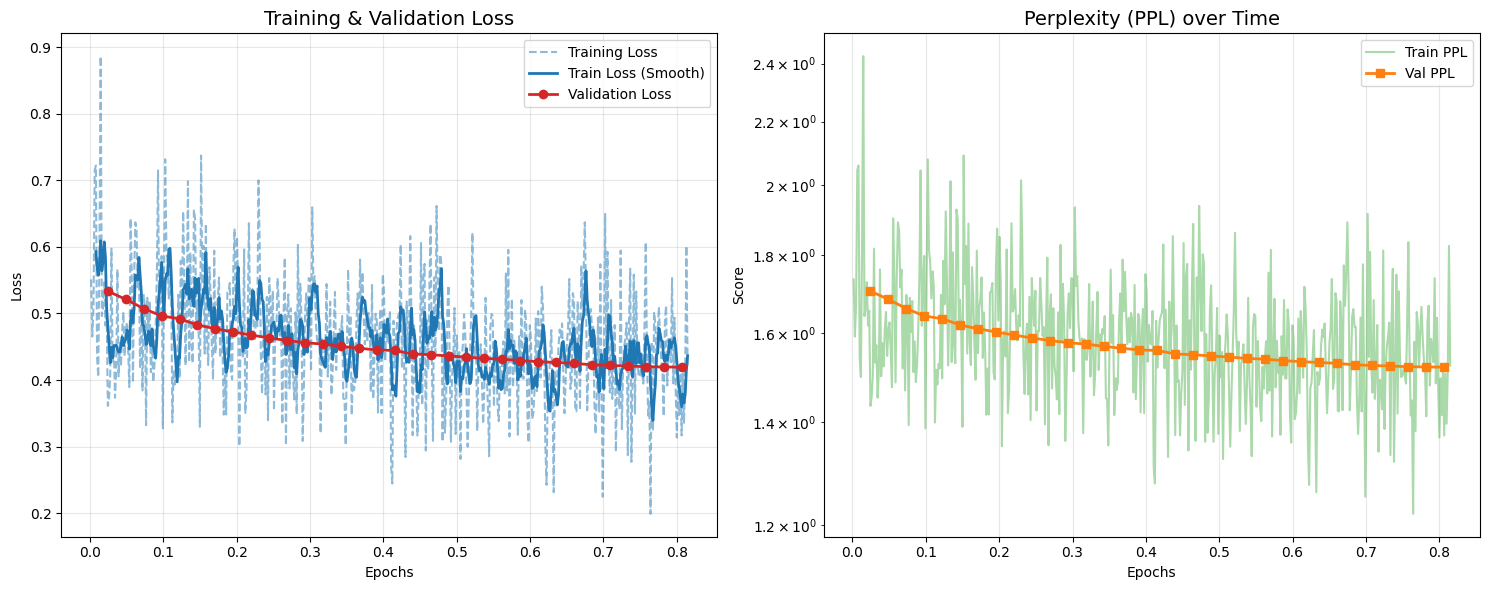

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def plot_training_results(trainer):
    history = trainer.state.log_history

    # 1. Trích xuất dữ liệu Training (thường có key 'loss')
    train_metrics = [x for x in history if 'loss' in x and 'eval_loss' not in x]
    train_loss = [x['loss'] for x in train_metrics]
    train_epochs = [x['epoch'] for x in train_metrics]

    # 2. Trích xuất dữ liệu Validation (thường có key 'eval_loss')
    val_metrics = [x for x in history if 'eval_loss' in x]
    val_loss = [x['eval_loss'] for x in val_metrics]
    val_epochs = [x['epoch'] for x in val_metrics]

    # Kiểm tra nhanh trong console
    print(f"Số điểm dữ liệu Train: {len(train_loss)}")
    print(f"Số điểm dữ liệu Validation: {len(val_loss)}")

    if len(val_loss) == 0:
        print("!!! CẢNH BÁO: Vẫn không thấy eval_loss. Kiểm tra lại eval_steps trong TrainingArguments.")
        # Thử in thử 1 dòng log cuối cùng để debug
        if history: print(f"Dòng log cuối cùng: {history[-1]}")

    plt.figure(figsize=(15, 6))

    # --- Biểu đồ 1: Loss ---
    plt.subplot(1, 2, 1)
    if train_loss:
        plt.plot(train_epochs, train_loss, label='Training Loss', color='#1f77b4', alpha=0.5, linestyle='--')
        # Vẽ thêm đường trung bình trượt (smooth) cho train loss vì nó đang bị zigzag mạnh
        smooth_train = np.convolve(train_loss, np.ones(5)/5, mode='valid')
        plt.plot(train_epochs[4:], smooth_train, color='#1f77b4', lw=2, label='Train Loss (Smooth)')

    if val_loss:
        plt.plot(val_epochs, val_loss, label='Validation Loss', color='#d62728', marker='o', markersize=6, linewidth=2)

    plt.title('Training & Validation Loss', fontsize=14)
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)

    # --- Biểu đồ 2: Perplexity (PPL) ---
    plt.subplot(1, 2, 2)
    if train_loss:
        plt.plot(train_epochs, np.exp(train_loss), label='Train PPL', color='#2ca02c', alpha=0.4)
    if val_loss:
        plt.plot(val_epochs, np.exp(val_loss), label='Val PPL', color='#ff7f0e', marker='s', markersize=6, linewidth=2)

    plt.title('Perplexity (PPL) over Time', fontsize=14)
    plt.xlabel('Epochs')
    plt.ylabel('Score')
    plt.yscale('log') # PPL thường giảm rất nhanh, dùng log scale sẽ dễ nhìn hơn
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# Gọi hàm
plot_training_results(trainer_sft)

# Nhận xét sau evaluate

-------
1. Phân tích đường Validation Loss & PPL (Rất Tốt) Xu hướng giảm ổn định: Đường màu đỏ (Validation Loss) và màu cam (Val PPL) đang đi xuống một cách đều đặn. Đây là dấu hiệu cực kỳ tốt. Nó cho thấy mô hình đang thực sự "học" được kiến thức từ tập dữ liệu và có khả năng áp dụng kiến thức đó lên dữ liệu mới (Validation set) chứ không chỉ học vẹt.Chưa có dấu hiệu Overfitting: Vì đường Validation Loss vẫn đang trên đà đi xuống và chưa có dấu hiệu ngóc đầu lên, nghĩa là bạn có thể train thêm (tăng max_steps) nếu muốn mô hình thông minh hơn nữa.
2. Phân tích đường Training Loss (Cần lưu ý)Biến động cực mạnh (Zigzag): Đường xanh đứt đoạn dao động rất lớn (từ 0.2 đến 0.7). Mặc dù đường trung bình (Smooth) có xu hướng đi ngang hoặc giảm nhẹ, nhưng sự nhiễu này cho thấy việc cập nhật trọng số đang hơi "vất vả".Lý do: Với per_device_train_batch_size = 2 và gradient_accumulation_steps = 4, tổng batch size thực tế của bạn là 8. Đối với các tác vụ yêu cầu logic cao như Luật hay Tâm lý, con số này hơi nhỏ, khiến mô hình bị "giật mình" bởi các mẫu dữ liệu khác nhau.
3. Chỉ số Perplexity (PPL)Con số ấn tượng: PPL của bạn đang nằm ở mức rất thấp (khoảng $1.3 \times 10^0$ đến $1.7 \times 10^0$, tức là quanh mức 1.3 - 1.7).Ý nghĩa: Điều này cực kỳ tốt! Nó cho thấy mô hình dự đoán từ tiếp theo trong tập Validation với độ tự tin rất cao. Với một mô hình nhỏ như Qwen 1.5B hoặc 4B, mức PPL dưới 2 là một kết quả rất hứa hẹn.

# Lưu lại .gguf

In [ ]:
# Save it to .gguf
model.save_pretrained_gguf(
    "Qwen2.5-1.5B-Instruct-TamlyVN",               # Tên thư mục lưu trữ
    tokenizer,
    quantization_method = "q4_k_m", # Phương pháp nén (q4_k_m là phổ biến nhất)
)

Unsloth: Merging model weights to 16-bit format...


config.json:   0%|          | 0.00/762 [00:00<?, ?B/s]

Found HuggingFace hub cache directory: /root/.cache/huggingface/hub
Checking cache directory for required files...
Cache check failed: model.safetensors not found in local cache.
Not all required files found in cache. Will proceed with downloading.
Checking cache directory for required files...
Cache check failed: tokenizer.model not found in local cache.
Not all required files found in cache. Will proceed with downloading.


Unsloth: Preparing safetensor model files:   0%|          | 0/1 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

...

Note: tokenizer.model not found (this is OK for non-SentencePiece models)


Unsloth: Merging weights into 16bit: 100%|██████████| 1/1 [01:13<00:00, 73.82s/it]


Unsloth: Merge process complete. Saved to `/content/Qwen2.5-1.5B-Instruct-TamlyVN`
Unsloth: Converting to GGUF format...
==((====))==  Unsloth: Conversion from HF to GGUF information
   \\   /|    [0] Installing llama.cpp might take 3 minutes.
O^O/ \_/ \    [1] Converting HF to GGUF f16 might take 3 minutes.
\        /    [2] Converting GGUF f16 to ['q4_k_m'] might take 10 minutes each.
 "-____-"     In total, you will have to wait at least 16 minutes.

Unsloth: Installing llama.cpp. This might take 3 minutes...
Unsloth: Updating system package directories
Unsloth: Cloning llama.cpp repository...
Unsloth: Building llama.cpp - please wait 1 to 3 minutes
Unsloth: Successfully installed llama.cpp!
Unsloth: Preparing converter script...


Unsloth: [1] Converting model into f16 GGUF format.
This might take 3 minutes...
Unsloth: Initial conversion completed! Files: ['Qwen2.5-1.5B-Instruct-TamlyVN_gguf/qwen2.5-1.5b-instruct.F16.gguf']
Unsloth: [2] Converting GGUF f16 into q4_k_m. This might take 10 minutes...
Unsloth: Model files cleanup...
Unsloth: All GGUF conversions completed successfully!
Generated files: ['Qwen2.5-1.5B-Instruct-TamlyVN_gguf/qwen2.5-1.5b-instruct.Q4_K_M.gguf']
Unsloth: example usage for text only LLMs: /root/.unsloth/llama.cpp/llama-cli --model Qwen2.5-1.5B-Instruct-TamlyVN_gguf/qwen2.5-1.5b-instruct.Q4_K_M.gguf -p "why is the sky blue?"
Unsloth: Saved Ollama Modelfile to Qwen2.5-1.5B-Instruct-TamlyVN_gguf/Modelfile
Unsloth: convert model to ollama format by running - ollama create model_name -f Qwen2.5-1.5B-Instruct-TamlyVN_gguf/Modelfile


{'save_directory': 'Qwen2.5-1.5B-Instruct-TamlyVN',
 'gguf_directory': 'Qwen2.5-1.5B-Instruct-TamlyVN_gguf',
 'gguf_files': ['Qwen2.5-1.5B-Instruct-TamlyVN_gguf/qwen2.5-1.5b-instruct.Q4_K_M.gguf'],
 'modelfile_location': 'Qwen2.5-1.5B-Instruct-TamlyVN_gguf/Modelfile',
 'want_full_precision': False,
 'is_vlm': False,
 'fix_bos_token': False}

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive
